Number Cross 3
--
    
<img src='https://www.janestreet.com/puzzles/jul16_puzzle.png' width=600 align='center'/>

Enter the digits 1 thru 9, or their negatives, in each of the squares in the crossword grid. The crossword clues represent the sum of the digits in each answer. Ignoring sign, no digit will appear more than once in any row or column in the completed grid. Also, every row and column of the completed grid has exactly one negative number.

For your answer, submit the sum of all numbers in the grid which share a border (horizontal or vertical) with one of the negative numbers.


In [1]:
import time
import itertools
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
from z3 import *

In [2]:
def _cellgroups(shape: np.array, rev = False) -> list[list[tuple]]:
    l = []
    temp = []
    
    for row, lst in enumerate(shape):
        if temp:
            l.append(temp)
            
        temp = []
        for col, cell in enumerate(lst):
            if cell != 0:
                if rev:
                    temp.append((col, row))

                else:
                    temp.append((row, col))
    
            elif temp:
                l.append(temp)
                temp = []
    if temp:
        l.append(temp)
        
    return l

def digsum(word):
    return Sum([digit for digit in word])

shape = [
    1,1,1,0,0,0,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,0,
    1,1,1,1,0,1,1,0,0,0,0,0,0,1,1,0,1,1,1,1,0,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,0,1,1,1,
    1,1,1,1,1,1,0,1,1,1,1,1,1,1,0,0,0,1,1,1
]

shape = np.array(shape).reshape(10,10)

a_idx = [1,4,8,9,11,12,13,15,16,17,19,23,26,27,28,29,30,31]
d_idx = [1,28,2,23,3,24,14,9,18,10,25,4,5,20,6,21,7,22]

a_tar = [24,14,10,25,0,19,41,23,6,-8,14,39,15,17,17,22,8,10]
d_tar = [17,1,6,21,35,4,30,8,4,19,7,32,13,22,30,9,8,30]

a = _cellgroups(shape)
b = _cellgroups(shape.T, rev=True)

n = shape.shape[0]
grid = np.array([[Int(f"X_{[j,i]}") for i in range(n)] for j in range(n)])
bool_grid = np.array([[Int(f"B_{[j,i]}") for i in range(n)] for j in range(n)])
d = {}
for k, v in enumerate(a):
    d[f"a{a_idx[k]}"] = {'target': a_tar[k], 'cells': [grid[i][j] for i,j in a[k]]}

for k, v in enumerate(b):
    d[f"d{d_idx[k]}"] = {'target': d_tar[k], 'cells': [grid[i][j] for i,j in b[k]]}

In [3]:
s = Tactic("qffd").solver()

#For bool grid, black squares are zero rest are 0 or 1
[[s.add(bool_grid[j][i] == 0) if cell == 0 else s.add(Or([bool_grid[j][i] == 0, bool_grid[j][i] == 1])) for i, cell in enumerate(row)] for j, row in enumerate(shape)]

#Only one of the bools can be true per row or column
for row in bool_grid:
    s += Sum([x for x in row]) == 1

for col in bool_grid.T:
    s += Sum([x for x in col]) == 1

for i, row in enumerate(bool_grid):
    for j, col in enumerate(bool_grid):
        s += Implies(bool_grid[i][j] == 1, grid[i][j] < 0)
        s += Implies(bool_grid[i][j] == 0, Or([grid[i][j] > 0, grid[i][j] == 0]))

#Zeroes in the black squares, 1-9 in the white squares
[[s.add(grid[j][i] == 0) if cell == 0 else s.add(grid[j][i] > -10, grid[j][i] < 10, grid[j][i] != 0) for i, cell in enumerate(row)] for j, row in enumerate(shape)]

#No repeats per row or column ignoring sign
for i, row in enumerate(grid):
    s += Distinct([If(x >= 0, x, -x) for j, x in enumerate(row) if shape[i][j] != 0])

for i, col in enumerate(grid.T):
    s += Distinct([If(x >= 0, x, -x) for j, x in enumerate(col) if shape.T[i][j] != 0])

#Digit sum is equal to target
for k, v in d.items():
    s += digsum(v['cells']) == v['target']

start = time.perf_counter()
if s.check() == sat:
    m = s.model()
    sol = np.array([[m[cell].as_long() for cell in row] for row in grid])
    print(sol)
    bool_sol = np.array([[m[cell].as_long() for cell in row] for row in bool_grid])
    print(bool_sol)

end = time.perf_counter()
print(f"Time elapsed is {(end - start):.2f} seconds")

[[ 7  8  9  0  0  0  5  4  6 -1]
 [ 1  2  7  0  3  4  6 -5  8  9]
 [ 4 -9  5  0  1  3  2  6  7  0]
 [ 3  1  6 -2  4  5  7  8  9  0]
 [ 2  4  8  9  0  7 -1  0  0  0]
 [ 0  0  0  1 -9  0  4  3  2  5]
 [ 0  5  2  7  6  8  9  1 -3  4]
 [ 0  3  1  8  5 -2  0  7  4  6]
 [ 6  7 -3  4  2  1  0  9  5  8]
 [-5  6  4  3  0  0  0  2  1  7]]
[[0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 1 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 1 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0]]
Time elapsed is 0.59 seconds


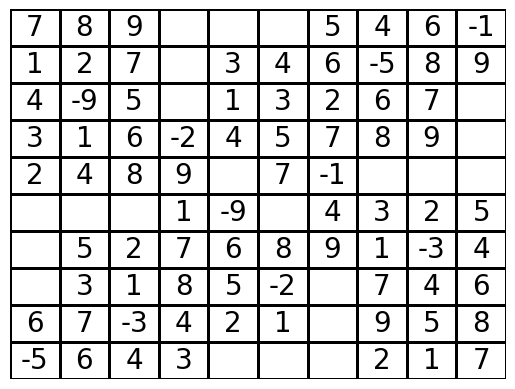

<Figure size 1000x1000 with 0 Axes>

Solution is 148


In [4]:
def grid_plotter(array: np.array) -> None:
    mask = array == 0
    ax = sns.heatmap(
        array, mask = mask, cmap=ListedColormap(['white']), annot=True, annot_kws={"fontsize":20, "color":"black"}, cbar=False, linewidths=1, linecolor="black",
        xticklabels = False, yticklabels = False
    )
    plt.figure(figsize = (10,10))
    plt.show()

grid_plotter(sol)

total = []
for i, row in enumerate(sol):
    for j, col in enumerate(row):
        if col < 0:
            if i - 1 >= 0:
                total.append(sol[i-1][j].item())
            if i + 1 < sol.shape[0]:
                total.append(sol[i+1][j].item())
            if j - 1 >= 0:
                total.append(sol[i][j-1].item())
            if j + 1 < sol.shape[0]:
                total.append(sol[i][j+1].item())
                
print(f"Solution is {sum(total)}")      